In [ ]:
from ihp import PDK
from ihp.cells.capacitors import cmim
from gsim.palace import DrivenSim
from pathlib import Path

PDK.activate()
yaml_file = Path("~/projects/IHP/ihp/s_parameters/ihp_stack.yaml").expanduser()

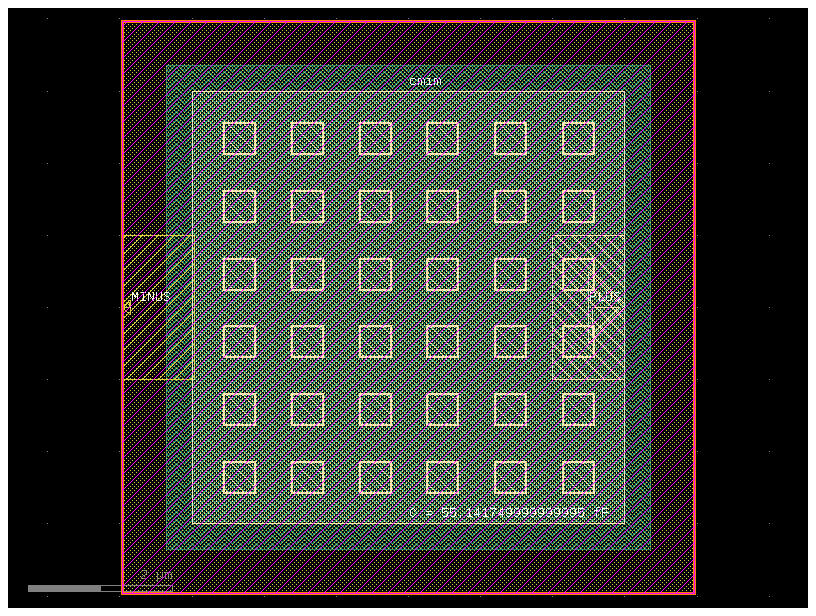

In [17]:
c = cmim(width=6.0, length=6.0)

#We exclude nofill layers
keep_layers = [
    (67, 0),   # Metal5drawing
    (67, 2),   # Metal5pin
    (36, 0),   # MIMdrawing
    #(129, 0),  # Vmimdrawing
    (69, 0),   # MemCapdrawing
    (126, 0),  # TopMetal1drawing
    (126, 2),  # TopMetal1pin
]

cc = c.extract(layers=keep_layers)
cc.add_ports(c.ports)

c.draw_ports()
c.plot()

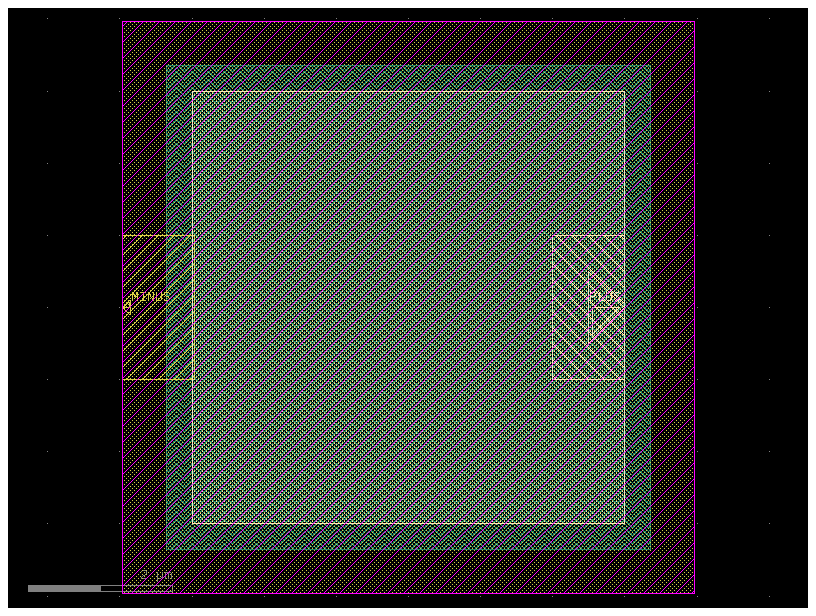

In [18]:
cc.plot()

We remove the Vmimdrawing layer, since otherwise mesh generation produces the following error:
```
Error   : Invalid boundary mesh (overlapping facets) on surface 48 surface 18
---------------------------------------------------------------------------
Exception                                 Traceback (most recent call last)
/tmp/ipykernel_661459/4234084370.py in ?()
      1 # If we try to mesh the geometry with planar_conductors=False, we get the following error:
      2 # Error   : Unknown model face with tag 7
      3 
----> 4 sim.mesh(preset="graded", refined_mesh_size=0.2)

~/projects/gsim/src/gsim/palace/driven.py in ?(self, preset, refined_mesh_size, max_mesh_size, margin, airbox_margin, fmax, planar_conductors, show_gui, model_name, verbose)
    662         # Extract ports
    663         palace_ports = extract_ports(component, stack)
    664 
    665         # Generate mesh (config is written separately by simulate() or write_config())
--> 666         return self._generate_mesh_internal(
    667             output_dir=output_dir,
    668             mesh_config=mesh_config,
    669             ports=palace_ports,

~/projects/gsim/src/gsim/palace/driven.py in ?(self, output_dir, mesh_config, ports, driven_config, model_name, verbose, write_config)
    461 
    462         if verbose:
    463             logger.info("Generating mesh in %s", output_dir)
    464 
--> 465         mesh_result = generate_mesh(
    466             component=component,
    467             stack=stack,
    468             ports=ports,

~/projects/gsim/src/gsim/palace/mesh/pipeline.py in ?(component, stack, ports, output_dir, config, model_name, driven_config, write_config, pec_blocks)
    205 
    206     output_dir = Path(output_dir)
    207 
    208     # Use new generator
--> 209     result = gen_mesh(
    210         component=component,
    211         stack=stack,
    212         ports=ports,

~/projects/gsim/src/gsim/palace/mesh/generator.py in ?(component, stack, ports, output_dir, model_name, refined_mesh_size, max_mesh_size, margin, air_margin, fmax, show_gui, driven_config, write_config, planar_conductors, refine_from_curves, pec_blocks, merge_via_distance)
    293             )
    294 
    295     finally:
    296         gmsh.clear()
--> 297         gmsh.finalize()
    298 
    299     # Build result (store groups for deferred config generation)
    300     result = MeshResult(

~/projects/gsim/.venv/lib/python3.12/site-packages/gmsh.py in ?(dim)
   2185             lib.gmshModelMeshGenerate(
   2186                 c_int(dim),
   2187                 byref(ierr))
   2188             if ierr.value != 0:
-> 2189                 raise Exception(logger.getLastError())

Exception: Invalid boundary mesh (overlapping facets) on surface 48 surface 18
```

In [19]:
# Checking the port layers.
cc.ports

["Port(self.name='MINUS', self.width=200, trans=r180 *1 -3.86,0, layer=Metal5pin (67/2), port_type=electrical)", "Port(self.name='PLUS', self.width=1000, trans=r0 *1 2.5,0, layer=TopMetal1pin (126/2), port_type=electrical)"]

By inspecting `cc.ports`, we observe that the port labeled *MINUS* appears first in the component’s port ordering. In gdsfactory, this ordering determines the port indexing, so *MINUS* is automatically assigned as port P1. Therefore, it must be set with `excited=True` to ensure that Palace excites P1 and correctly computes the scattering parameters $S_{11}$ and $S_{21}$.


In [20]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-cmim")
sim.set_geometry(cc)

sim.set_stack(substrate_thickness=2.0,air_above=2.0)

# MINUS is assigned as P1 by gdsfactory (component port order), so it must be
# excited=True to ensure Palace excites P1 and generates S[1][1] and S[2][1].
sim.add_port("MINUS",from_layer="metal5",to_layer="topmetal1",geometry="via",length=6.0,excited=True)
sim.add_port("PLUS",from_layer="metal5",to_layer="topmetal1",geometry="via",length=6.0,excited=False)

sim.set_driven(fmin=1e9, fmax=100e9, num_points=60)

print(sim.validate_config())

Validation: PASSED


In [ ]:
#TODO: investigate why XY dimension is much larger than expected.
sim.mesh(preset="graded", refined_mesh_size=0.2)

Mesh Summary
Dimensions: 107.9 x 107.9 x 20.3 µm
Nodes:      3,267
Elements:   23,501
Tetrahedra: 18,413
Edge length: 0.10 - 56.86 µm
Quality:    0.612 (min: 0.006)
SICN:       0.662 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (11):
  - metal5_xy [4]
  - metal5_z [5]
  - topmetal1_xy [6]
  - topmetal1_z [7]
  - P1 [8]
  - P2 [9]
  - SiO2__None [10]
  - SiO2__passive [11]
  - passive__None [12]
  - air__passive [13]
  - air__None [14]
----------------------------------------
Mesh:   runs/palace-sim-cmim/palace.msh

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:37:00.103 ( 557.645s) [    76903D06C080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:37:00.114 ( 557.655s) [    76903D06C080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:37:00.149 ( 557.690s) [    76903D06C080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


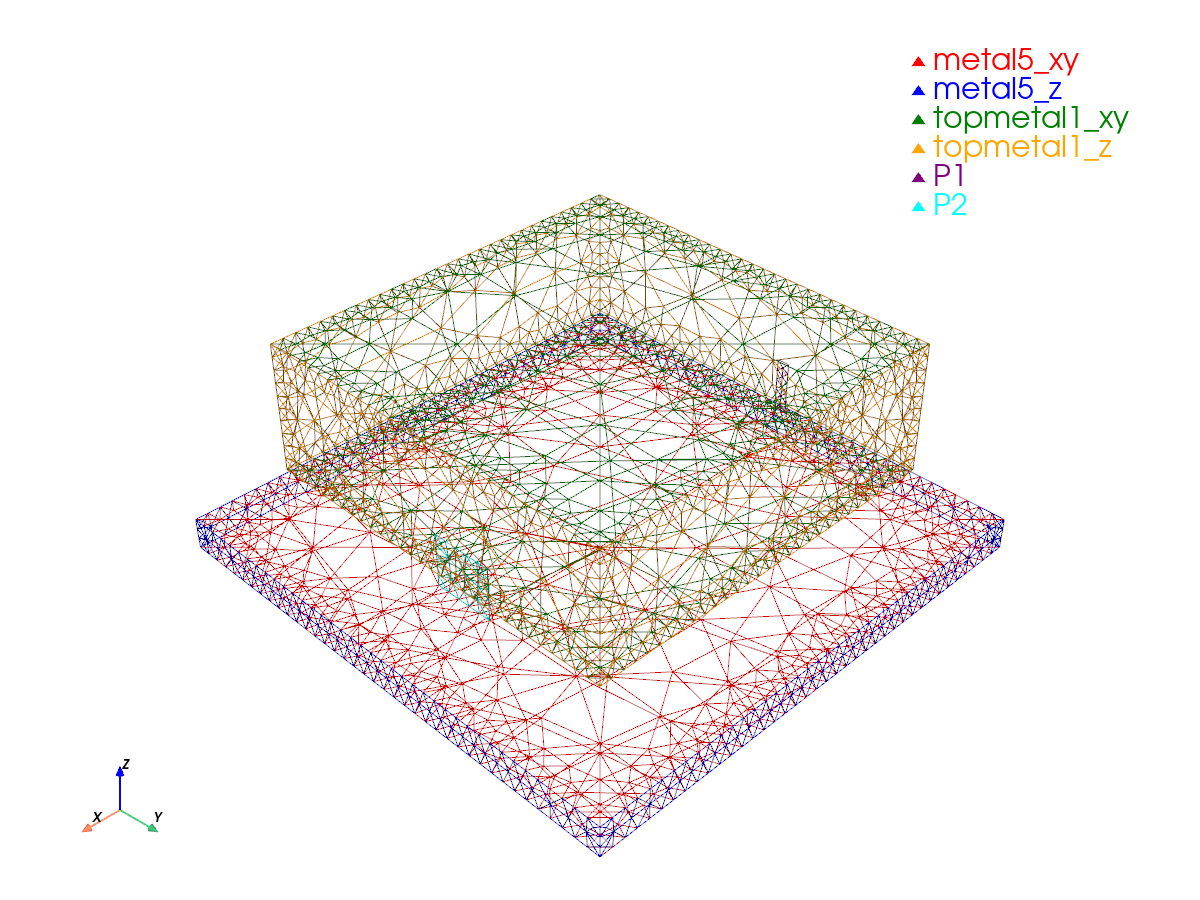

In [22]:
sim.plot_mesh(show_groups=["metal","vmim","P"], interactive=False)

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:37:00.391 ( 557.932s) [    76903D06C080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:37:00.401 ( 557.942s) [    76903D06C080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: failed to open /dev/dri/renderD128: Permission denied

libEGL warning: failed to open /dev/dri/renderD128: Permission denied

2026-04-01 01:37:00.427 ( 557.969s) [    76903D06C080]vtkEGLRenderWindowInter:218   WARN| EGL device index: 0 could not be initialized. Trying other devices...


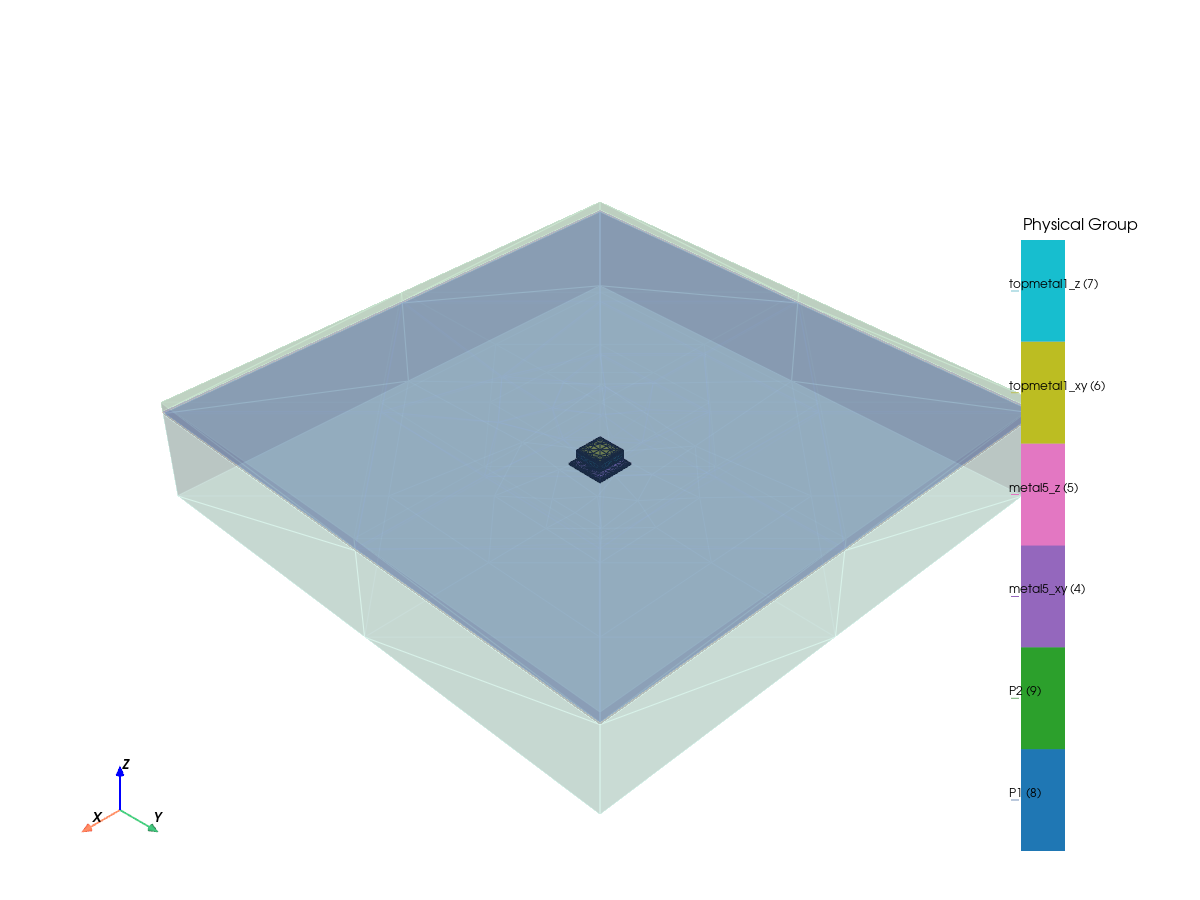

In [23]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["air__None","air__passive","SiO2__None","SiO2__passive","passive__None"],
)

In [24]:
results = sim.run(parent_dir="runs")

  palace-7b9f8cd2  completed  0m 35s
Extracting results.tar.gz...
Downloaded 11 files to runs/sim-data-palace-7b9f8cd2


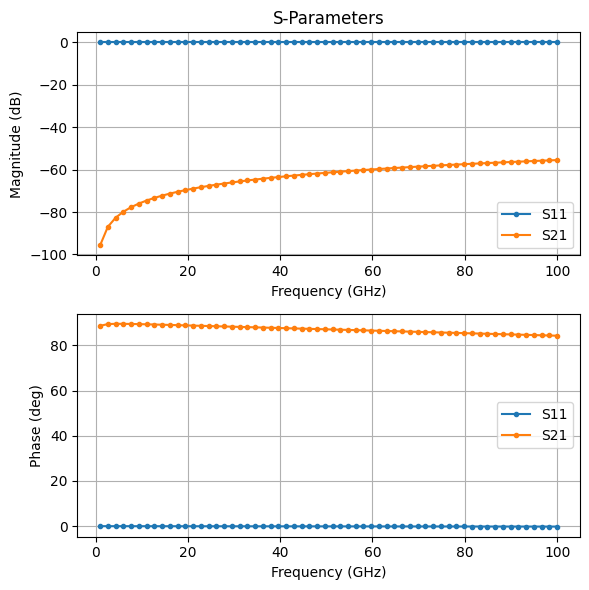

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(results["port-S.csv"])
df.columns = df.columns.str.strip()  # Remove whitespace from column names

freq = df["f (GHz)"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))

# Magnitude plot
ax1.plot(freq, df["|S[1][1]| (dB)"], marker=".", label="S11")
ax1.plot(freq, df["|S[2][1]| (dB)"], marker=".", label="S21")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("Magnitude (dB)")
ax1.set_title("S-Parameters")
ax1.legend()
ax1.grid(True)

# Phase plot
ax2.plot(freq, df["arg(S[1][1]) (deg.)"], marker=".", label="S11")
ax2.plot(freq, df["arg(S[2][1]) (deg.)"], marker=".", label="S21")
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Phase (deg)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()